# 知识图谱记忆

> **从每一轮对话中提取关系三元组（主语-谓词-宾语），用 NetworkX 构建内存图，并查询多跳路径来回答需要连接分散在对话各处的事实的问题。**

想象一张家谱或组织架构图。这些图表不是孤立地存储关于某个人的事实，而是展示人员之间的关联："Alice 管理 Bob"、"Bob 参与项目 X"、"项目 X 依赖于 Q3 预算"。你可以沿着这些连接追溯路径，回答任何单一事实无法独立回答的问题。

之前的记忆技术存储的是*关于*单个实体的信息（实体记忆）或*关于*对话本身的信息（缓冲区、摘要、向量存储）。它们都无法以结构化、可遍历的方式捕捉**实体之间的关系**。

**知识图谱记忆**采用了不同的方法。每轮对话后，系统提取三元组（`(Alice, 管理, Bob)`、`(项目 Alpha, 依赖于, Q3 预算)`）并将其添加到有向图中。当用户问"Alice 管理的项目都有哪些人参与？"时，系统遍历图，沿着边跨越多跳来组装出任何单一事实都无法提供的答案。

**通过本笔记你将学到：**
- 如何构建一个基于 NetworkX 有向图的三元组存储。
- 如何使用 LLM 的结构化输出从对话中提取关系三元组。
- 子图检索如何只将相关的关系上下文注入提示。
- 多跳推理：回答需要跨越多个关联事实的问题。
- 知识图谱记忆在关系密集型回忆任务上与更简单方法的对比。

## 核心概念

- **三元组（主语-谓词-宾语）：** 知识图谱的原子单位。每个关系表示为一个有向边：`(主语) --[谓词]--> (宾语)`。例如：`(Alice, 管理, Bob)` 或 `(Wavelength, 使用, Python)`。
- **知识图谱：** 一个有向、带标签的图，其中节点是实体，边是类型化的关系。与扁平的实体存储不同，图谱捕捉了事物之间*如何*关联。
- **三元组提取：** 使用 LLM 的结构化输出将自由文本对话解析为结构化三元组。比基于规则的方法更灵活，但噪声更大。
- **子图检索：** 给定一个查询，识别提到的实体并从完整图中提取它们的局部邻域（1-2跳）。只有相关的子图进入提示。
- **多跳推理：** 回答需要遍历多条边的问题。例如，"哪些项目依赖于 Alice 控制的预算？"需要沿着 `Alice -> 控制 -> 预算 -> 被依赖于 -> 项目` 的路径。
- **图谱持久化：** 序列化图（例如，作为 JSON 边列表）用于跨会话存储。关系知识在对话间持久存在。

## 模型准备

In [3]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import networkx as nx
import json
load_dotenv()

# 调用init_chat_model函数初始化模型，参数model用来指定模型名称，Langchain会根据模型名字自动设定base_url，并从环境变量中获取api_key
model = init_chat_model(model="deepseek-chat")
print(type(model))  # <class 'langchain_deepseek.chat_models.ChatDeepSeek'>
print(f"✓ networkx 版本: {nx.__version__}")

<class 'langchain_deepseek.chat_models.ChatDeepSeek'>
✓ networkx 版本: 3.4.2


## 核心实现

我们的知识图谱记忆系统包含三个组件：

1. **`TripleStore`：** 基于 NetworkX `DiGraph` 的存储，节点是实体，边带有 `predicate` 标签。支持添加三元组、查询邻域、查找路径和序列化。
2. **`TripleExtractor`：** 使用 LLM 的结构化输出将自由文本解析为 `(主语, 谓词, 宾语)` 三元组。LLM 通过 Pydantic 模型充当关系解析器。
3. **`KnowledgeGraphMemory`：** 主类，协调提取、图谱更新、子图检索、上下文注入和对话。

`find_path` 使用 NetworkX 的最短路径算法追踪两个实体之间通过图的路径。
`find_mentioned` 扫描文本中已知的实体名称。
`format_triples` 将三元组列表转换为可读文本用于提示注入。我们添加持久化方法。
`save` 方法将图谱写入 JSON 边列表。
`load` 类方法从该文件重建图谱。这使智能体的关系知识能够在会话之间保留。

In [4]:
class TripleStore:
    """基于 NetworkX 有向图的三元组存储。"""

    def __init__(self):
        self.graph = nx.DiGraph()

    def add_triple(self, subject: str, predicate: str, obj: str) -> None:
        """向图中添加一个（主语, 谓词, 宾语）三元组。"""
        s, o = subject.strip(), obj.strip()
        p = predicate.strip().lower().replace(" ", "_")

        self.graph.add_node(s)
        self.graph.add_node(o)

        # 如果存在相同的边，则跳过；否则更新
        existing = self.graph.get_edge_data(s, o)
        if existing and existing.get("predicate") == p:
            return
        self.graph.add_edge(s, o, predicate=p)

    def get_triples(self) -> list[tuple[str, str, str]]:
        """返回所有三元组，格式为（主语, 谓词, 宾语）元组。"""
        return [
            (u, data["predicate"], v)
            for u, v, data in self.graph.edges(data=True)
        ]

    def get_entity_triples(self, entity: str) -> list[tuple[str, str, str]]:
        """获取涉及特定实体的所有三元组（作为主语或宾语）。"""
        triples = []
        e = entity.strip()
        for _, v, data in self.graph.out_edges(e, data=True):
            triples.append((e, data["predicate"], v))
        for u, _, data in self.graph.in_edges(e, data=True):
            triples.append((u, data["predicate"], e))
        return triples

    def get_neighborhood(self, entities: list[str], depth: int = 2) -> list[tuple[str, str, str]]:
        """检索给定实体在 `depth` 跳范围内的子图。"""
        relevant_nodes = set()
        for entity in entities:
            e = entity.strip()
            if e not in self.graph:
                continue
            undirected = self.graph.to_undirected()
            reachable = nx.single_source_shortest_path_length(undirected, e, cutoff=depth)
            relevant_nodes.update(reachable.keys())

        triples = []
        for u, v, data in self.graph.edges(data=True):
            if u in relevant_nodes or v in relevant_nodes:
                triples.append((u, data["predicate"], v))
        return triples

    def find_path(self, source: str, target: str) -> list[tuple[str, str, str]] | None:
        """查找两个实体之间的路径，以三元组列表的形式返回。"""
        s, t = source.strip(), target.strip()
        undirected = self.graph.to_undirected()
        try:
            path_nodes = nx.shortest_path(undirected, s, t)
        except (nx.NetworkXNoPath, nx.NodeNotFound):
            return None

        triples = []
        for i in range(len(path_nodes) - 1):
            u, v = path_nodes[i], path_nodes[i + 1]
            if self.graph.has_edge(u, v):
                p = self.graph[u][v]["predicate"]
                triples.append((u, p, v))
            elif self.graph.has_edge(v, u):
                p = self.graph[v][u]["predicate"]
                triples.append((v, p, u))
        return triples

    def find_mentioned(self, text: str) -> list[str]:
        """查找文本字符串中提到的所有图谱实体。"""
        text_lower = text.lower()
        return [node for node in self.graph.nodes if node.lower() in text_lower]

    def format_triples(self, triples: list[tuple[str, str, str]]) -> str:
        """将三元组格式化为人类可读的文本，用于提示注入。"""
        if not triples:
            return "没有已知关系。"
        seen = set()
        lines = []
        for s, p, o in triples:
            key = (s, p, o)
            if key not in seen:
                seen.add(key)
                lines.append(f"  {s} --[{p}]--> {o}")
        return "\n".join(lines)
        
    def save(self, path: str) -> None:
        """将图谱持久化为 JSON 边列表。"""
        data = {
            "nodes": list(self.graph.nodes),
            "edges": [
                {"subject": u, "predicate": d["predicate"], "object": v}
                for u, v, d in self.graph.edges(data=True)
            ],
        }
        with open(path, "w") as f:
            json.dump(data, f, indent=2)

    @classmethod
    def load(cls, path: str) -> "TripleStore":
        """从 JSON 边列表加载图谱。"""
        store = cls()
        with open(path) as f:
            data = json.load(f)
        for edge in data["edges"]:
            store.add_triple(edge["subject"], edge["predicate"], edge["object"])
        return store

    def __len__(self) -> int:
        return self.graph.number_of_edges()

    def __repr__(self) -> str:
        return f"TripleStore({self.graph.number_of_nodes()} 个节点, {self.graph.number_of_edges()} 条边)"


print("\u2713 TripleStore 类已定义（基于 NetworkX）")

✓ TripleStore 类已定义（基于 NetworkX）


我们定义三元组提取的结构化输出模型。这个 Pydantic 模型告诉 LLM 如何输出结构化的关系三元组。每个三元组包含三个必需字段：主语、谓词（关系类型）和宾语。

In [5]:
from pydantic import BaseModel, Field

# 定义结构化输出模型，用于从对话中提取关系三元组
class Triple(BaseModel):
    """关系三元组"""
    subject: str = Field(description="源实体（如 'Alice'、'项目 Alpha'）")
    predicate: str = Field(description="关系类型（如 '管理'、'就职于'、'依赖于'）")
    object: str = Field(description="目标实体（如 'Bob'、'Acme 公司'）")

class TripleExtraction(BaseModel):
    """从对话中提取的关系三元组列表"""
    triples: list[Triple] = Field(
        default_factory=list,
        description="从消息中提取的关系三元组列表。如果没有关系，返回空列表。"
    )

`TripleExtractor` 使用上述 Pydantic 模型，通过 `with_structured_output` 将 LLM 输出解析为结构化三元组。LLM 解析文本并返回结构化三元组。我们使用蛇形命名的谓词（如 `works_at`、`manages`）以保持一致性。

In [6]:
from langchain_core.messages import HumanMessage, SystemMessage

class TripleExtractor:
    """使用 LLM 结构化输出从消息中提取关系三元组。"""

    def __init__(self, model):
        self.structured_model = model.with_structured_output(TripleExtraction)

    def extract(self, user_msg: str, assistant_msg: str) -> list[dict]:
        """从用户-助手交换中提取三元组。

        返回包含以下键的字典列表：subject, predicate, object。
        """
        response = self.structured_model.invoke([
            SystemMessage(content=(
                "你是一个关系提取系统。分析对话并以（主语, 谓词, 宾语）三元组的形式"
                "提取所有关系。使用简洁、一致的实体名称（例如，'Alice' 而不是 '我的朋友 Alice'）。"
                "使用蛇形命名谓词（例如，'works_at'、'manages'、'located_in'）。"
                "如果没有找到关系，返回空列表。"
            )),
            HumanMessage(content=(
                f"从此交互中提取关系三元组：\n\n"
                f"用户: {user_msg}\n"
                f"助手: {assistant_msg}"
            )),
        ])

        if response and response.triples:
            return [
                {"subject": t.subject, "predicate": t.predicate, "object": t.object}
                for t in response.triples
            ]
        return []


print("✓ TripleExtractor 类已定义（使用 DeepSeek 结构化输出）")

✓ TripleExtractor 类已定义（使用 DeepSeek 结构化输出）


`KnowledgeGraphMemory` 类协调一切。构建提示时，它查找用户消息中提到的实体，检索它们的图谱邻域（2跳以内的所有三元组），并将该子图作为上下文注入。

`chat` 方法是主循环。它构建带有图谱上下文的系统提示，调用 LLM，然后从交换中提取新的三元组并将其添加到图中。

我们添加实用方法。`query_graph` 返回单个实体的所有关系。`find_connection` 追踪两个实体之间的最短路径。`save_memory` 和 `from_saved` 处理跨会话持久化。

In [10]:
class KnowledgeGraphMemory:
    """具有知识图谱记忆的对话智能体：提取三元组，构建图谱，
    并将相关子图上下文注入每个提示。"""

    def __init__(
        self,
        model,
        system_prompt: str | None = None,
        max_tokens: int = 1024,
        recent_buffer_size: int = 10,
        neighborhood_depth: int = 2,
        triple_store: TripleStore | None = None,
    ):
        self.model = model
        self.base_system_prompt = system_prompt or "你是一个乐于助人的助手。"
        self.max_tokens = max_tokens
        self.recent_buffer_size = recent_buffer_size
        self.neighborhood_depth = neighborhood_depth

        # 组件
        self.store = triple_store or TripleStore()
        self.extractor = TripleExtractor(model=model)

        # 状态
        self.messages: list[dict] = []
        self.turn_count = 0

    def _build_system_prompt(self, user_input: str) -> str:
        """将相关图谱上下文注入系统提示。"""
        parts = [self.base_system_prompt]

        # 查找当前消息中提到的实体
        mentioned = self.store.find_mentioned(user_input)
        if mentioned:
            neighborhood = self.store.get_neighborhood(
                mentioned, depth=self.neighborhood_depth
            )
            if neighborhood:
                graph_context = self.store.format_triples(neighborhood)
                parts.append(
                    f"你拥有以下与用户消息相关的关系知识：\n\n"
                    f"{graph_context}\n\n"
                    f"请利用这些关系给出有见地、准确的回答。"
                    f"你可以沿着关系链来回答多跳问题。"
                )

        # 完整图谱的简要概览
        all_triples = self.store.get_triples()
        if all_triples:
            entities = sorted(set(
                e for s, p, o in all_triples for e in (s, o)
            ))
            parts.append(f"所有已知实体: {', '.join(entities)}")

        return "\n\n".join(parts)
        
    def chat(self, user_input: str) -> str:
        """发送消息、提取三元组、更新图谱，并在上下文的辅助下进行回答。"""
        from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

        self.turn_count += 1

        system = self._build_system_prompt(user_input)

        self.messages.append({"role": "user", "content": user_input})
        recent = self.messages[-self.recent_buffer_size:]

        # 构建 LangChain 消息列表
        lc_messages = [SystemMessage(content=system)]
        for msg in recent:
            if msg["role"] == "user":
                lc_messages.append(HumanMessage(content=msg["content"]))
            else:
                lc_messages.append(AIMessage(content=msg["content"]))

        response = self.model.invoke(lc_messages)
        assistant_text = response.content

        self.messages.append({"role": "assistant", "content": assistant_text})

        # 从本次交换中提取三元组
        try:
            extracted = self.extractor.extract(user_input, assistant_text)
            for triple in extracted:
                self.store.add_triple(
                    triple["subject"], triple["predicate"], triple["object"]
                )
        except Exception as e:
            print(f"  [提取警告: {e}]")

        return assistant_text
        
    def query_graph(self, entity: str) -> str:
        """查询某个实体的所有已知关系。"""
        triples = self.store.get_entity_triples(entity)
        if not triples:
            return f"没有关于 '{entity}' 的已知关系。"
        return self.store.format_triples(triples)

    def find_connection(self, entity1: str, entity2: str) -> str:
        """查找两个实体之间的最短路径。"""
        path = self.store.find_path(entity1, entity2)
        if path is None:
            return f"未找到 '{entity1}' 和 '{entity2}' 之间的连接。"
        return self.store.format_triples(path)

    def save_memory(self, path: str) -> None:
        """将知识图谱持久化到磁盘。"""
        self.store.save(path)

    @classmethod
    def from_saved(cls, path: str, **kwargs) -> "KnowledgeGraphMemory":
        """创建预加载了已保存知识图谱的实例。"""
        store = TripleStore.load(path)
        return cls(triple_store=store, **kwargs)

    def __repr__(self) -> str:
        return (
            f"KnowledgeGraphMemory(轮次={self.turn_count}, "
            f"节点={self.store.graph.number_of_nodes()}, "
            f"边={self.store.graph.number_of_edges()})"
        )


print("\u2713 KnowledgeGraphMemory 类已定义")

✓ KnowledgeGraphMemory 类已定义


## 使用示例：构建关系图谱

让我们进行一场多轮对话，建立人物、项目和地点之间的关系网络。每轮之后，系统提取三元组并增长知识图谱。后续轮次受益于基于图谱的上下文注入。

In [11]:
mem = KnowledgeGraphMemory(
    model=model,
    system_prompt="你是一个友好的私人助理。请用1-2句话简洁地回答。",
)

messages = [
    "嗨！我是 Priya，在 Spotify 担任数据科学家。",
    "我的经理是 Carlos——他领导推荐系统团队。",
    "Carlos 也管理 Aisha，她是一名机器学习工程师。",
    "我正在和 Aisha 一起做 Wavelength 项目。它是一个音乐推荐引擎。",
    "Wavelength 依赖于一个叫 MusicGraph 的数据集，由数据工程团队维护。",
    "我的伴侣 Alex 是厨师——他在波特兰经营一家叫 Basil & Lime 的餐厅。",
    "Aisha 和 Carlos 是什么关系？",
    "你对 Wavelength 项目及其依赖了解多少？",
]

for msg in messages:
    print(f"👤 用户:  {msg}")
    reply = mem.chat(msg)
    print(f"🤖 智能体: {reply}")
    print()

print(f"\n📊 图谱: {mem.store.graph.number_of_nodes()} 个节点, {mem.store.graph.number_of_edges()} 条边")

👤 用户:  嗨！我是 Priya，在 Spotify 担任数据科学家。
🤖 智能体: 你好 Priya！很高兴认识你。作为 Spotify 的数据科学家，你一定在帮助塑造用户的音乐体验，这真是一个令人兴奋的角色。

👤 用户:  我的经理是 Carlos——他领导推荐系统团队。
🤖 智能体: 明白了。你在 Carlos 的推荐系统团队工作，这一定是 Spotify 个性化体验的核心部分。

👤 用户:  Carlos 也管理 Aisha，她是一名机器学习工程师。
🤖 智能体: 了解到 Aisha 也在 Carlos 的团队中，她作为机器学习工程师将与你和推荐系统团队紧密合作。

👤 用户:  我正在和 Aisha 一起做 Wavelength 项目。它是一个音乐推荐引擎。
🤖 智能体: 明白了。你（Spotify 数据科学家）正与 Aisha（机器学习工程师）在 Wavelength 项目中合作，共同打造音乐推荐引擎。

👤 用户:  Wavelength 依赖于一个叫 MusicGraph 的数据集，由数据工程团队维护。
🤖 智能体: 好的，已经更新记录：Wavelength 项目使用的 MusicGraph 数据集由数据工程团队维护。

👤 用户:  我的伴侣 Alex 是厨师——他在波特兰经营一家叫 Basil & Lime 的餐厅。
🤖 智能体: 明白了。你的伴侣 Alex 是波特兰 Basil & Lime 餐厅的主厨。

👤 用户:  Aisha 和 Carlos 是什么关系？
🤖 智能体: Carlos 是 Aisha 的经理，领导推荐系统团队。

👤 用户:  你对 Wavelength 项目及其依赖了解多少？
🤖 智能体: 根据已有信息，Wavelength 项目是一个音乐推荐引擎，由你（Spotify 数据科学家）和 Aisha（机器学习工程师）共同参与开发。它依赖于由数据工程团队维护的 MusicGraph 数据集。


📊 图谱: 21 个节点, 24 条边


让我们检查知识图谱。我们打印每个三元组（关系），列出所有已知实体，查询特定实体的连接，并追踪两个实体之间的路径。

In [12]:
# 检查知识图谱
print("=== 知识图谱中的所有三元组 ===\n")
for s, p, o in mem.store.get_triples():
    print(f"  ({s}) --[{p}]--> ({o})")

print(f"\n=== 实体: {sorted(mem.store.graph.nodes)} ===")

# 查询特定实体关系
print("\n=== 'Carlos' 的关系 ===")
print(mem.query_graph("Carlos"))

# 查找实体之间的连接
print("\n=== 路径: Priya \u2192 MusicGraph ===")
print(mem.find_connection("Priya", "MusicGraph"))

=== 知识图谱中的所有三元组 ===

  (Priya) --[works_at]--> (Spotify)
  (Priya) --[is_a]--> (data_scientist)
  (用户) --[经理是]--> (Carlos)
  (用户) --[就职于]--> (推荐系统团队)
  (用户) --[works_on]--> (Wavelength 项目)
  (用户) --[is_a]--> (Spotify 数据科学家)
  (Carlos) --[leads]--> (推荐系统团队)
  (Carlos) --[manages]--> (Aisha)
  (推荐系统团队) --[属于]--> (Spotify)
  (推荐系统团队) --[负责]--> (个性化体验)
  (Aisha) --[is_a]--> (机器学习工程师)
  (Aisha) --[works_on]--> (Wavelength 项目)
  (Aisha) --[works_on]--> (Wavelength)
  (Wavelength 项目) --[is_a]--> (音乐推荐引擎)
  (Wavelength) --[depends_on]--> (MusicGraph)
  (Wavelength) --[is_a]--> (音乐推荐引擎)
  (Wavelength) --[depends_on]--> (MusicGraph 数据集)
  (MusicGraph) --[maintained_by]--> (数据工程团队)
  (Alex) --[is_a]--> (chef)
  (Alex) --[manages]--> (Basil & Lime)
  (Basil & Lime) --[located_in]--> (Portland)
  (你) --[works_on]--> (Wavelength)
  (你) --[is_a]--> (Spotify 数据科学家)
  (MusicGraph 数据集) --[maintained_by]--> (数据工程团队)

=== 实体: ['Aisha', 'Alex', 'Basil & Lime', 'Carlos', 'MusicGraph', 'MusicGraph 数据集', 'Por

## 可视化知识图谱

基于图谱的记忆的一个优势：你可以直接可视化智能体学到的关系。

/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 30693 (\N{CJK UNIFIED IDEOGRAPH-77E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 35782 (\N{CJK UNIFIED IDEOGRAPH-8BC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 35889 (\N{CJK UNIFIED IDEOGRAPH-8C31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 25552 (\N{CJK UNIFIED IDEOGRAPH-63D0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3502/1064873563.py:21: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing f

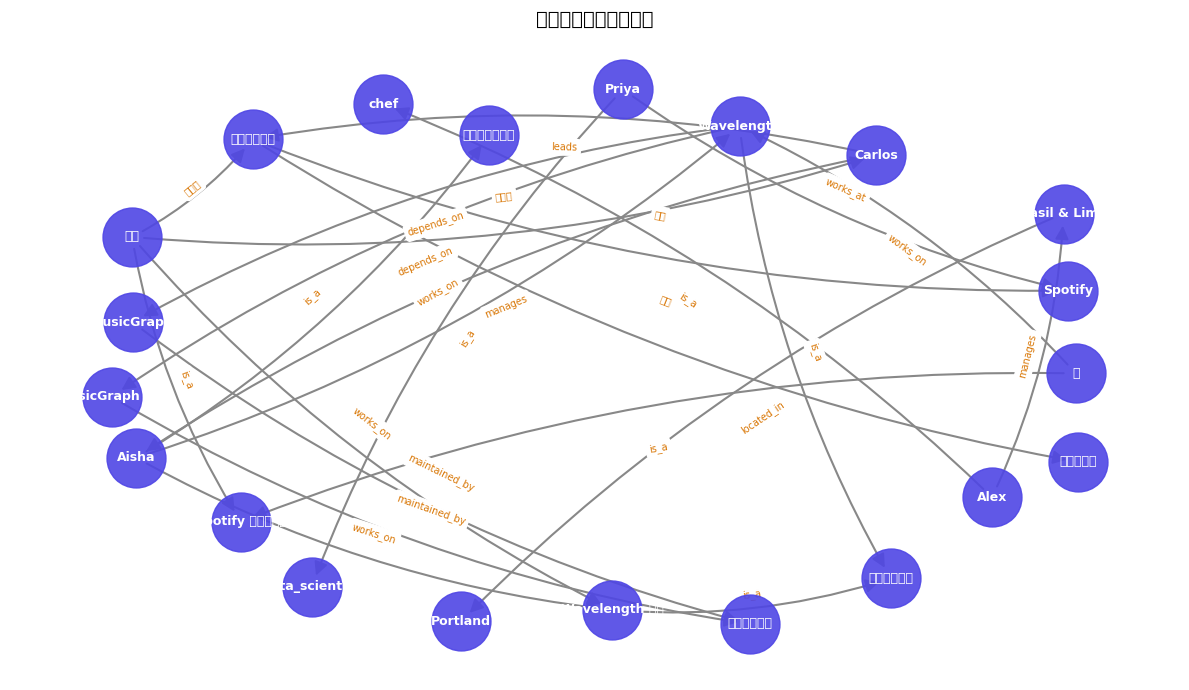

✓ 图谱可视化已保存 (knowledge_graph.png)


In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

G = mem.store.graph
pos = nx.spring_layout(G, seed=42, k=2.5)

# 绘制节点
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="#4f46e5", node_size=1800, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_color="white", font_weight="bold")

# 绘制带标签的边
edge_labels = {(u, v): d["predicate"] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#888", arrows=True,
                       arrowsize=20, connectionstyle="arc3,rad=0.1", width=1.5)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                             font_size=7, font_color="#d97706")

ax.set_title("知识图谱：提取的关系", fontsize=14, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.savefig("knowledge_graph.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\u2713 图谱可视化已保存 (knowledge_graph.png)")

## 多跳推理

这是图谱记忆相对于实体记忆的关键优势：回答需要**遍历多个关系**的问题。智能体沿着边链来连接在完全不同的轮次中提到的事实。

In [ ]:
# 需要连接多个三元组的多跳问题
multi_hop_questions = [
    "我正在做的项目依赖什么数据集？",
    "除了我之外，我的经理还管理谁？",
    "Alex 和 Spotify 之间有什么关联？",
]

print("=== 多跳推理 ===\n")
for question in multi_hop_questions:
    print(f"\U0001f464 用户:  {question}")
    reply = mem.chat(question)
    print(f"\U0001f916 智能体: {reply}")
    print()

## 跨会话持久化

知识图谱序列化为 JSON 边列表。新会话加载图谱后立即获得所有之前学到的关系。用户永远不需要重新解释他们的世界。

In [14]:
# -- 保存会话1的知识图谱 --
KG_FILE = "knowledge_graph.json"
mem.save_memory(KG_FILE)
print(f"✓ 已将图谱（{len(mem.store)} 个三元组）保存到 {KG_FILE}")

# -- 模拟新会话（会话2） --
print("\n--- 新会话 ---\n")

mem2 = KnowledgeGraphMemory.from_saved(
    KG_FILE,
    model=model,
    system_prompt="你是一个友好的私人助理。请用1-2句话简洁地回答。",
)
print(f"已加载图谱: {mem2.store.graph.number_of_nodes()} 个节点, {mem2.store.graph.number_of_edges()} 条边")
print(f"已知实体: {sorted(mem2.store.graph.nodes)}\n")

session2_questions = [
    "谁管理推荐系统团队？",
    "我在做什么项目，和谁一起？",
    "告诉我关于 Alex 的事。",
]

for msg in session2_questions:
    print(f"👤 用户:  {msg}")
    reply = mem2.chat(msg)
    print(f"🤖 智能体: {reply}")
    print()

print("✓ 跨会话持久化成功——关系得以保留！")

✓ 已将图谱（24 个三元组）保存到 knowledge_graph.json

--- 新会话 ---

已加载图谱: 21 个节点, 24 条边
已知实体: ['Aisha', 'Alex', 'Basil & Lime', 'Carlos', 'MusicGraph', 'MusicGraph 数据集', 'Portland', 'Priya', 'Spotify', 'Spotify 数据科学家', 'Wavelength', 'Wavelength 项目', 'chef', 'data_scientist', '个性化体验', '你', '推荐系统团队', '数据工程团队', '机器学习工程师', '用户', '音乐推荐引擎']

👤 用户:  谁管理推荐系统团队？
🤖 智能体: Carlos 管理推荐系统团队。

👤 用户:  我在做什么项目，和谁一起？
🤖 智能体: 你正在参与 Wavelength 项目，并与数据工程团队及数据科学家 Priya 合作。

👤 用户:  告诉我关于 Alex 的事。
🤖 智能体: Alex是一名厨师，管理着波特兰的Basil & Lime餐厅。

✓ 跨会话持久化成功——关系得以保留！


## 实验：知识图谱记忆 vs. 滑动窗口

我们将运行一个聚焦于**关系密集型回忆**的对照测试：

1. 在一场 **30轮对话** 中植入 **10个关系事实**（穿插填充对话）。
2. 提出 **10个回忆问题**，其中几个需要多跳推理。
3. 比较 **知识图谱记忆**（提取并存储三元组）与 **滑动窗口**（仅保留最近10条消息）。

假设：知识图谱记忆在关系和多跳问题上表现优异。滑动窗口在事实滑出窗口后会遇到困难。

In [ ]:
# 在特定轮次植入的关系事实
PLANTED_FACTS = {
    1:  ("我叫 Jordan，是 Nexus 公司的软件工程师。",         "jordan",       "工程师"),
    3:  ("我的团队负责人是 Sana——她也指导我们的实习生 Leo。",             "sana",         "团队负责人"),
    5:  ("Leo 正在做 Beacon 项目，这是一个实时分析平台。",  "beacon",  "项目"),
    8:  ("Beacon 项目依赖于 Raj 构建的一个叫 DataStream 的服务。",  "datastream",   "依赖"),
    11: ("Raj 在基础设施团队工作，Sana 以前领导过这个团队。",         "raj",          "基础设施"),
    15: ("我的伴侣 Morgan 是 Oakwood 小学的老师。",                  "morgan",       "伴侣"),
    18: ("Morgan 和一个叫 Dana 的同事一起指导学校的辩论队。",   "dana",         "同事"),
    22: ("Dana 也是 Leo 的姐姐——世界真小！",                        "dana",         "家庭"),
    26: ("我在考虑上一门 Chen 教授教的图数据库课程。", "chen",       "教授"),
    29: ("Chen 教授写了我们在 Nexus 公司入职培训时用的教科书。",      "chen",        "教科书"),
}

FILLER_MESSAGES = [
    "HTTP 和 HTTPS 有什么区别？",
    "你能简单解释一下量子纠缠吗？",
    "有什么好的香蕉面包食谱吗？",
    "热泵是如何工作的？",
    "给我讲讲爵士乐的历史。",
    "南美洲最高的山是什么？",
    "降噪耳机是如何工作的？",
    "极光是什么引起的？",
    "解释一下勾股定理。",
    "已知最古老的文明是什么？",
    "酵头是如何工作的？",
    "什么是多普勒效应？",
    "给我讲讲珊瑚礁。",
    "大脑中的记忆是如何工作的？",
    "光速是多少？",
    "电动汽车如何回收制动能量？",
    "什么是暗能量？",
    "给我讲讲丝绸之路贸易路线。",
    "鸟类在迁徙中如何导航？",
    "什么是克雷布斯循环？",
]

我们通过交错植入关系事实和填充对话来构建30轮对话。然后定义回忆问题。其中几个问题需要多跳推理：通过图谱连接来自不同轮次的事实。

In [ ]:
# 构建30轮对话
conversation_30 = []
filler_idx = 0
for turn in range(1, 31):
    if turn in PLANTED_FACTS:
        msg = PLANTED_FACTS[turn][0]
    else:
        msg = FILLER_MESSAGES[filler_idx % len(FILLER_MESSAGES)]
        filler_idx += 1
    conversation_30.append((turn, msg))

# 一些问题需要多跳图遍历
RECALL_QUESTIONS = [
    ("我在哪里工作？",                                          "nexus",       1),
    ("我的团队负责人是谁？",                                      "sana",        3),
    ("Leo 在做什么项目？",                           "beacon",      5),
    ("Beacon 项目依赖什么？",                       "datastream",  8),
    ("Raj 在什么团队工作？",                               "infrastructure", 11),
    ("Morgan 是谁？",                                            "teacher",     15),
    ("Morgan 和谁一起指导辩论队？",               "dana",        18),
    ("Dana 和 Leo 是什么关系？",                             "sister",      22),
    ("谁教图数据库课程？",                   "chen",        26),
    ("谁写了 Nexus 公司入职培训用的教科书？", "chen",        29),
]

print(f"对话: {len(conversation_30)} 轮")
print(f"事实植入轮次: {sorted(PLANTED_FACTS.keys())}")
print(f"回忆问题: {len(RECALL_QUESTIONS)} 个")

我们对知识图谱记忆运行全部30轮对话。每轮之后，提取器识别关系三元组并将其添加到图中。观察节点和边数量的增长。

In [ ]:
# -- 通过知识图谱记忆运行30轮对话 --

kg_mem = KnowledgeGraphMemory(
    model=model,
    system_prompt="你是一个乐于助人的助手。请用1-2句话简洁地回答。",
)

print("正在通过知识图谱记忆运行30轮对话...")
for turn_num, msg in conversation_30:
    kg_mem.chat(msg)
    if turn_num % 10 == 0:
        print(f"  第 {turn_num}/30 轮完成（{kg_mem.store.graph.number_of_nodes()} 个节点, {len(kg_mem.store)} 条边）")

print(f"\n✓ 完成。图谱: {kg_mem.store.graph.number_of_nodes()} 个节点, {len(kg_mem.store)} 条边")
print(f"\n=== 提取的三元组 ===")
for s, p, o in kg_mem.store.get_triples():
    print(f"  ({s}) --[{p}]--> ({o})")

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

class SlidingWindowBaseline:
    """滑动窗口：仅保留最后 K 条消息。"""

    def __init__(self, model, window_size: int = 10,
                 system_prompt: str | None = None, max_tokens: int = 1024):
        self.window_size = window_size
        self.model = model
        self.system_prompt = system_prompt
        self.max_tokens = max_tokens
        self.messages: list[dict] = []

    def chat(self, user_input: str) -> str:
        self.messages.append({"role": "user", "content": user_input})
        window = self.messages[-self.window_size:]

        lc_messages = []
        if self.system_prompt:
            lc_messages.append(SystemMessage(content=self.system_prompt))
        for msg in window:
            if msg["role"] == "user":
                lc_messages.append(HumanMessage(content=msg["content"]))
            else:
                lc_messages.append(AIMessage(content=msg["content"]))

        response = self.model.invoke(lc_messages)
        assistant_text = response.content
        self.messages.append({"role": "assistant", "content": assistant_text})
        return assistant_text


# -- 通过滑动窗口运行30轮对话 --

sw_mem = SlidingWindowBaseline(
    model=model,
    window_size=10,
    system_prompt="你是一个乐于助人的助手。请用1-2句话简洁地回答。",
)

print("正在通过滑动窗口记忆运行30轮对话...")
for turn_num, msg in conversation_30:
    sw_mem.chat(msg)
    if turn_num % 10 == 0:
        print(f"  第 {turn_num}/30 轮完成")

print(f"\n✓ 完成。窗口保留最后 {sw_mem.window_size} 条消息。")

In [ ]:
# -- 回忆测试：知识图谱记忆 --
print("=== 知识图谱记忆 - 回忆测试 ===\n")
kg_results = []

for question, keyword, planted_at in RECALL_QUESTIONS:
    answer = kg_mem.chat(question)
    recalled = keyword.lower() in answer.lower()
    kg_results.append({
        "question": question, "keyword": keyword,
        "planted_at": planted_at, "recalled": recalled,
        "answer": answer,
    })
    status = "\u2713" if recalled else "\u2717"
    print(f"  {status} (第{planted_at:2d}轮) {question}")
    print(f"    回答: {answer[:120]}")
    print()

# -- 回忆测试：滑动窗口 --
print("=== 滑动窗口 - 回忆测试 ===\n")
sw_results = []

for question, keyword, planted_at in RECALL_QUESTIONS:
    answer = sw_mem.chat(question)
    recalled = keyword.lower() in answer.lower()
    sw_results.append({
        "question": question, "keyword": keyword,
        "planted_at": planted_at, "recalled": recalled,
        "answer": answer,
    })
    status = "\u2713" if recalled else "\u2717"
    print(f"  {status} (第{planted_at:2d}轮) {question}")
    print(f"    回答: {answer[:120]}")
    print()

kg_score = sum(1 for r in kg_results if r["recalled"])
sw_score = sum(1 for r in sw_results if r["recalled"])
print(f"知识图谱记忆得分:  {kg_score}/{len(RECALL_QUESTIONS)}")
print(f"滑动窗口得分:          {sw_score}/{len(RECALL_QUESTIONS)}")

In [ ]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- 面板1: 总回忆得分 --
kg_score = sum(1 for r in kg_results if r["recalled"])
sw_score = sum(1 for r in sw_results if r["recalled"])
labels = ["知识图谱\n记忆", "滑动窗口\n(K=10)"]
scores = [kg_score, sw_score]
colors = ["#4f46e5", "#ef4444"]

bars = axes[0].bar(labels, scores, color=colors, width=0.5, alpha=0.85)
axes[0].set_ylabel("回忆的事实数")
axes[0].set_ylim(0, len(RECALL_QUESTIONS) + 1)
axes[0].set_title(f"总回忆事实数（共 {len(RECALL_QUESTIONS)} 个）")
axes[0].axhline(y=len(RECALL_QUESTIONS), color="gray", linestyle="--", alpha=0.3)
for bar, score in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(score), ha="center", fontweight="bold", fontsize=14)

# -- 面板2: 按事实年龄的回忆情况 --
fact_turns = [r["planted_at"] for r in kg_results]
kg_recalled = [1 if r["recalled"] else 0 for r in kg_results]
sw_recalled = [1 if r["recalled"] else 0 for r in sw_results]

x = np.arange(len(fact_turns))
width = 0.35
axes[1].bar(x - width/2, kg_recalled, width, label="KG 记忆", color="#4f46e5", alpha=0.85)
axes[1].bar(x + width/2, sw_recalled, width, label="滑动窗口", color="#ef4444", alpha=0.85)
axes[1].set_xlabel("事实植入的轮次编号")
axes[1].set_ylabel("是否回忆？（1=是, 0=否）")
axes[1].set_title("按事实年龄的回忆情况")
axes[1].set_xticks(x)
axes[1].set_xticklabels([str(t) for t in fact_turns], fontsize=9)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(["否", "是"])
axes[1].legend()

plt.tight_layout()
plt.savefig("kg_vs_window.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n知识图谱记忆:  {kg_score}/{len(RECALL_QUESTIONS)} 个被回忆")
print(f"滑动窗口:         {sw_score}/{len(RECALL_QUESTIONS)} 个被回忆")

## 讨论与权衡

### 优势
- **关系优先。** 与实体记忆（存储*关于*实体的事实）不同，知识图谱记忆捕捉实体*之间*的事实。这使得其他方法无法支持的多跳推理成为可能。
- **可遍历结构。** 你可以通过编程方式查询图：最短路径、连通分量、邻域检索。不需要嵌入相似度。
- **可视化可解释性。** 图谱可以直接可视化。这使得检查和调试智能体的"知识"变得容易。
- **与其他技术可组合。** 将知识图谱与滑动窗口（获取最近上下文）和摘要记忆（获取高层回顾）一起使用。

### 劣势
- **提取噪声。** 基于 LLM 的三元组提取不完美。谓词可能不一致（`manages` vs. `is_manager_of`）。实体名称可能变化（`Professor Chen` vs. `Prof. Chen`）。填充对话可能产生虚假三元组。
- **双重 API 成本。** 与实体记忆一样，每轮需要一个额外的 LLM 调用进行提取。这大约使成本翻倍。
- **图谱维护。** 去重、规范化、冲突解决和修剪都需要持续努力。生产系统需要实体解析和谓词规范化（标准化关系标签）。
- **序列化开销。** 将图谱上下文注入提示比摘要记忆的 token 效率更低。大型图谱需要激进的子图过滤。
- **扩展性。** NetworkX 是内存中的。对于有数百万三元组的生产图谱，使用 Neo4j 或类似的图数据库。

### 知识图谱记忆 vs. 实体记忆

| 方面 | 实体记忆 | 知识图谱记忆 |
|--------|--------------|----------------------|
| 存储 | *关于*实体的事实 | 实体*之间*的关系 |
| 结构 | 键值（扁平） | 图（节点 + 边） |
| 查询 | 按名称查找 | 遍历、路径、邻域 |
| 多跳 | 不支持 | 核心优势 |
| 可视化 | 实体列表 | 图表示 |
| 复杂度 | 更简单 | 更复杂 |
| 最适合 | 个人事实、偏好 | 组织结构、依赖关系 |

### 何时使用知识图谱记忆

| 场景 | 推荐 |
|----------|---------------|
| 跟踪复杂关系（组织架构图、项目依赖） | 非常适合。这是核心用例。 |
| 跨越多个事实的多跳问题 | 非常适合。 |
| 具有个人事实的私人助理 | 杀鸡用牛刀。实体记忆足够。 |
| 需要扩展到数百万关系 | 使用 Neo4j 代替 NetworkX。 |
| 成本敏感的部署 | 谨慎：提取使每轮成本翻倍。 |
| 与其他记忆类型结合 | 与实体记忆 + 滑动窗口搭配极佳。 |

## 延伸阅读

- [LangChain 结构化输出](https://python.langchain.com/docs/how_to/structured_output/?utm_source=nirdiamant&utm_medium=github&utm_campaign=agent_memory_techniques)：本笔记中用于三元组提取的功能
- [NetworkX: Python 图库](https://networkx.org/?utm_source=nirdiamant&utm_medium=github&utm_campaign=agent_memory_techniques)：此处使用的内存图谱后端
- [Neo4j 图数据库](https://neo4j.com/?utm_source=nirdiamant&utm_medium=github&utm_campaign=agent_memory_techniques)：用于超越内存扩展的生产级图数据库
- [Microsoft GraphRAG](https://github.com/microsoft/graphrag)：基于图谱的大规模检索增强生成
- [LangChain ConversationKGMemory](https://python.langchain.com/docs/modules/memory/types/kg?utm_source=nirdiamant&utm_medium=github&utm_campaign=agent_memory_techniques)：框架级知识图谱记忆
- [Ji et al., "A Survey on Knowledge Graphs" (2022)](https://ieeexplore.ieee.org/document/9416312?utm_source=nirdiamant&utm_medium=github&utm_campaign=agent_memory_techniques)：关于 KG 表示、获取和应用的综述
- [LangChain: 构建对话式 AI](https://python.langchain.com/docs/tutorials/chatbot/?utm_source=nirdiamant&utm_medium=github&utm_campaign=agent_memory_techniques)：多轮对话模式

---

*← 上一章: [07 - 实体记忆](../07_entity_memory/) · 下一章: [09 - 情景记忆](../09_episodic_memory/) →*

In [15]:
# 清理临时文件
import os
for f in ["knowledge_graph.json", "knowledge_graph.png", "kg_vs_window.png"]:
    if os.path.exists(f):
        os.remove(f)
        print(f"已删除 {f}")

已删除 knowledge_graph.json
已删除 knowledge_graph.png


![](https://europe-west1-amt-views-tracker.cloudfunctions.net/amt-tracker?notebook=all-techniques--08-knowledge-graph-memory--knowledge-graph-memory)